# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
# Preparation

import pandas as pd
import numpy as np

# Load data
data = pd.read_csv('taxi.csv')

# Convert datetime column and set it as index
data['datetime'] = pd.to_datetime(data['datetime'])
data = data.set_index('datetime').sort_index()

# Basic validation before resampling
print("Raw data shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())
print("Duplicate timestamps:", data.index.duplicated().sum())
print("Missing values:\n", data.isna().sum())
print("Index is sorted:", data.index.is_monotonic_increasing)

# Check whether the original time series is continuous at 10-minute intervals
expected_index = pd.date_range(start=data.index.min(), end=data.index.max(), freq='10min')
print("Missing timestamps in original series:", len(expected_index.difference(data.index)))

# Resample by one hour using sum because we need total taxi orders per hour
data = data.resample('1h').sum()

# Final prepared dataset overview
print("\nResampled data shape:", data.shape)
print("First rows after hourly resampling:")
display(data.head())

print("\nLast rows after hourly resampling:")
display(data.tail())

print("\nSummary statistics:")
display(data.describe())

Raw data shape: (26496, 1)
Date range: 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Duplicate timestamps: 0
Missing values:
 num_orders    0
dtype: int64
Index is sorted: True
Missing timestamps in original series: 0

Resampled data shape: (4416, 1)
First rows after hourly resampling:


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43



Last rows after hourly resampling:


,num_orders
datetime,
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223
2018-08-31 23:00:00,205



Summary statistics:


,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The dataset contains historical taxi order counts recorded every 10 minutes from March 1, 2018 to August 31, 2018. The target variable is `num_orders`, which represents the number of taxi orders placed during each time interval. Since the task is to predict the number of orders for the next hour, the series was resampled to hourly frequency by summing the 10-minute observations within each hour.

During preparation, the dataset was checked for common time series quality issues. No missing values were found in the `num_orders` column, there were no duplicate timestamps, and the datetime index was already sorted correctly. A continuity check also confirmed that no 10-minute timestamps were missing from the original series, so the data is complete and consistent for modeling.

After hourly resampling, the dataset contains 4,416 observations. The average hourly number of orders is about 84, with substantial variation over time, as shown by a standard deviation of about 45. The minimum value is 0 and the maximum is 462, indicating periods of both very low and very high demand. These patterns suggest that the series likely contains trend and seasonal behavior, which should be explored in the analysis stage and incorporated into model building.

</div>

## Analysis

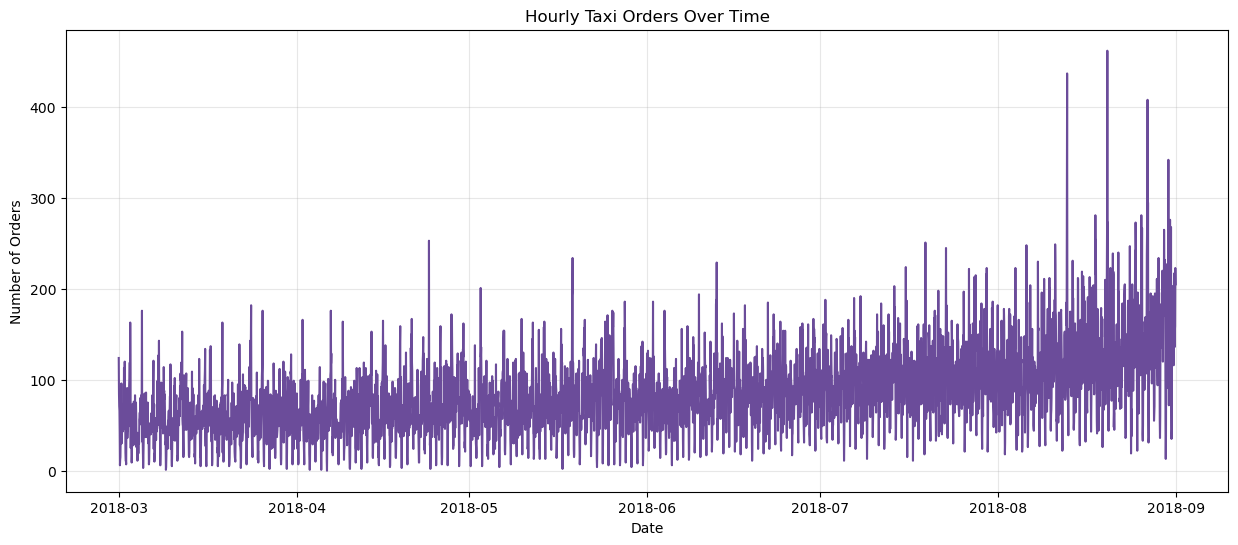

In [2]:
# 3.1 Time Series Overview

import matplotlib.pyplot as plt


plt.figure(figsize=(15, 6))
plt.plot(data.index, data['num_orders'], color='#6B4C9A')
plt.title('Hourly Taxi Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.grid(True, alpha=0.3)
plt.show()


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The hourly taxi order series shows a clear upward movement over time, especially from July into August, which indicates that overall demand increases across the observed period. At the same time, the plot contains frequent short-term fluctuations and several sharp spikes, meaning taxi demand is highly variable from hour to hour. The largest peaks appear closer to the end of the dataset, suggesting that both the average level of demand and the amplitude of fluctuations rise over time.

The repeated wave-like pattern throughout the series also suggests the presence of seasonality, likely connected to daily demand cycles. Since the series shows both trend and recurring variation, it does not appear to be stationary in its raw form. This is important for modeling because the prediction task will likely benefit from time-based features such as lag values, hour of day, and rolling statistics rather than relying only on the original target series.

</div>

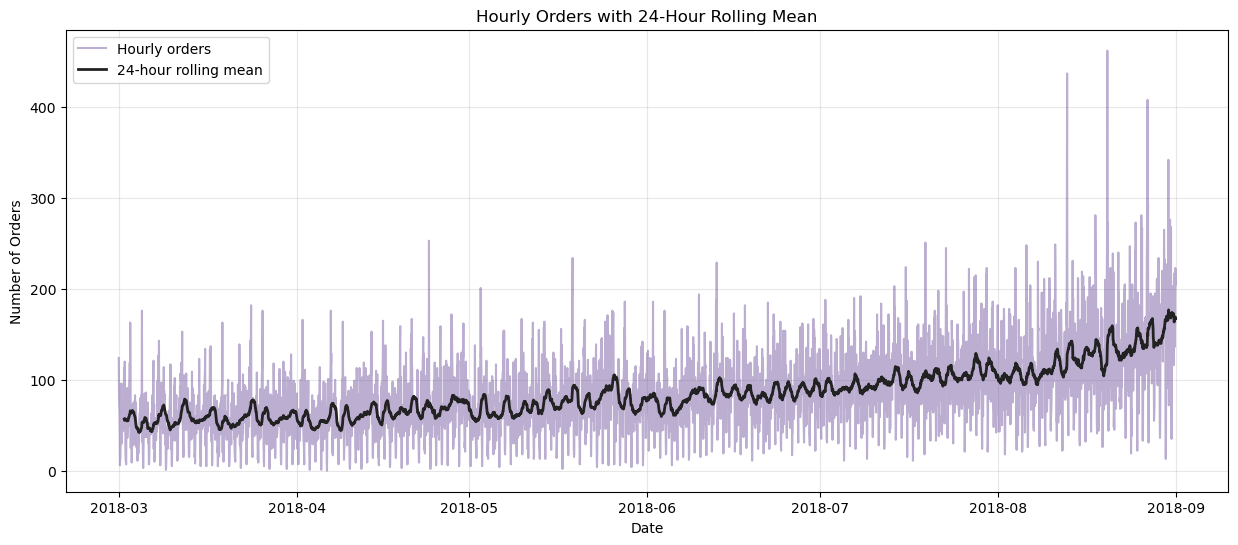

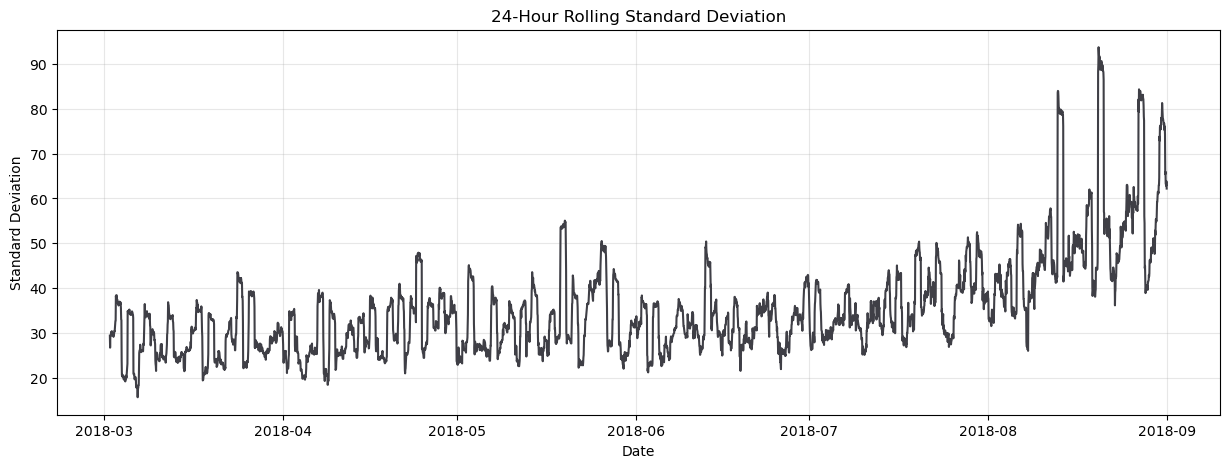

In [3]:
# 3.2 Rolling Statistics

rolling_mean = data['num_orders'].rolling(24).mean()
rolling_std = data['num_orders'].rolling(24).std()

plt.figure(figsize=(15, 6))
plt.plot(data.index, data['num_orders'], color='#6B4C9A', alpha=0.45, label='Hourly orders')
plt.plot(data.index, rolling_mean, color='#222222', linewidth=2, label='24-hour rolling mean')
plt.title('Hourly Orders with 24-Hour Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(data.index, rolling_std, color='#3F3F46')
plt.title('24-Hour Rolling Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The rolling statistics confirm the pattern seen in the original time series. The 24-hour rolling mean increases gradually over time and rises more sharply toward the final part of the dataset, which indicates that the overall level of taxi demand is not constant. This supports the presence of a trend component in the series.

The 24-hour rolling standard deviation also changes over time and becomes noticeably larger in the later months. This means that the variability of hourly taxi demand is increasing, especially near the end of the observed period. In other words, both the mean and the variance are unstable across time.

These results suggest that the original series is non-stationary. For modeling, this means the algorithm should not rely only on raw values. Instead, it will likely benefit from engineered time series features such as lag variables, calendar-based features, and rolling statistics that help capture changing patterns in demand.

</div>

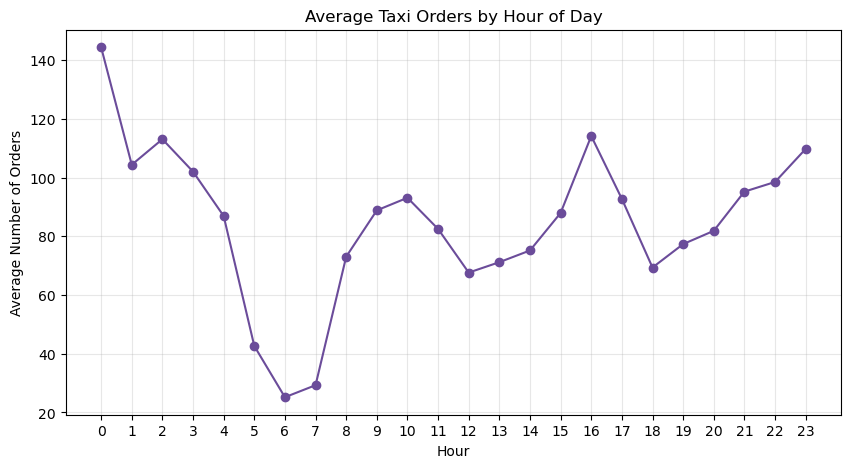

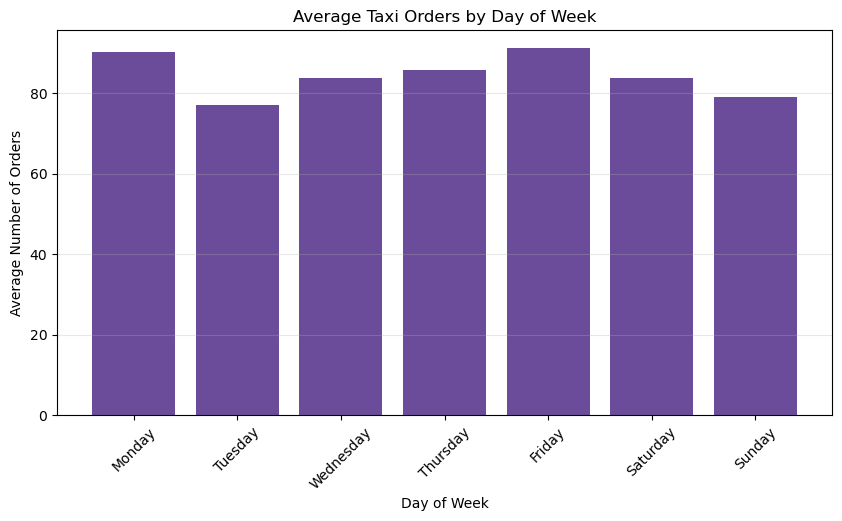

Average orders by hour:


,avg_num_orders
hour,
0,144.402174
1,104.364130
2,113.070652
3,102.021739
4,86.907609
5,42.630435
6,25.173913
7,29.271739
8,73.048913



Average orders by day of week:


,avg_num_orders
day_of_week,
0,90.246795
1,77.011218
2,83.754808
3,85.660494
4,91.140432
5,83.847756
6,78.991987


In [4]:
# 3.3 Seasonal Patterns

seasonal_data = data.copy()
seasonal_data['hour'] = seasonal_data.index.hour
seasonal_data['day_of_week'] = seasonal_data.index.dayofweek

hourly_pattern = seasonal_data.groupby('hour')['num_orders'].mean()
daily_pattern = seasonal_data.groupby('day_of_week')['num_orders'].mean()

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o', color='#6B4C9A')
plt.title('Average Taxi Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Number of Orders')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(day_labels, daily_pattern.values, color='#6B4C9A')
plt.title('Average Taxi Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Average orders by hour:")
display(hourly_pattern.to_frame(name='avg_num_orders'))

print("\nAverage orders by day of week:")
display(daily_pattern.to_frame(name='avg_num_orders'))

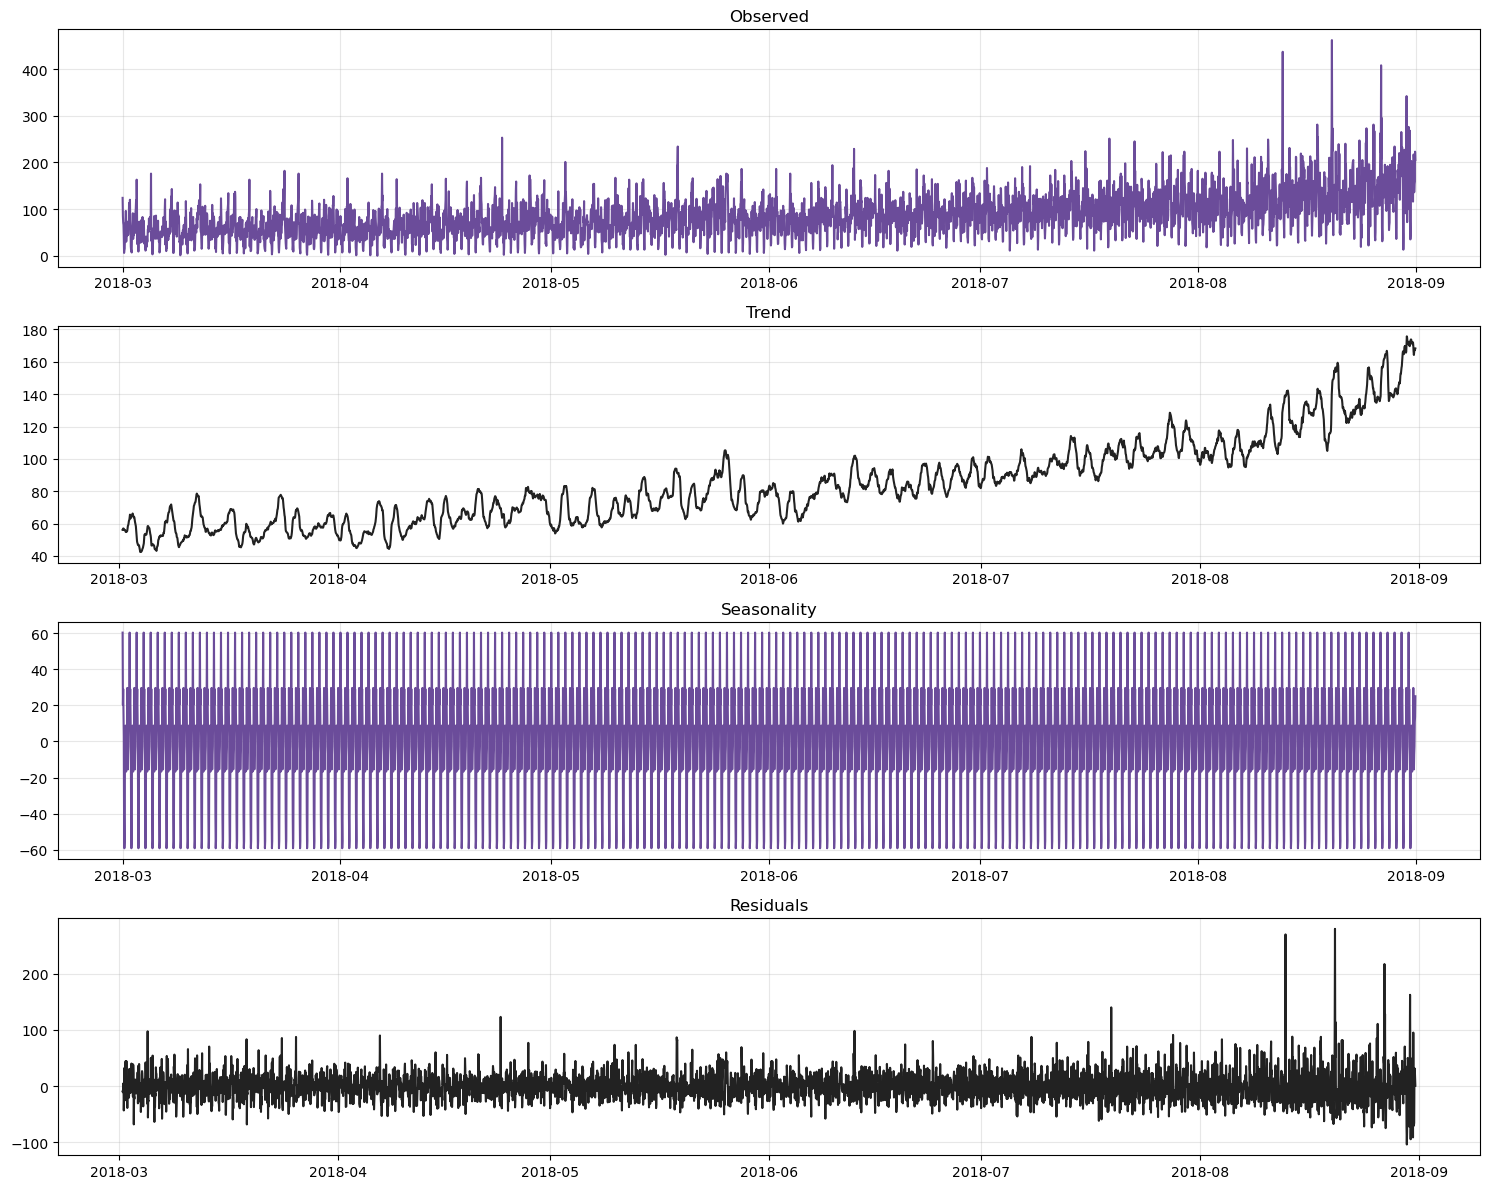

In [5]:
# 3.4 Seasonal Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(data['num_orders'], model='additive', period=24)

plt.figure(figsize=(15, 12))

plt.subplot(4, 1, 1)
plt.plot(decomposition.observed, color='#6B4C9A')
plt.title('Observed')
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, color='#222222')
plt.title('Trend')
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, color='#6B4C9A')
plt.title('Seasonality')
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.plot(decomposition.resid, color='#222222')
plt.title('Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The seasonal decomposition provides a clearer breakdown of the internal structure of the hourly taxi order series. The observed component reflects the original data and shows substantial short-term fluctuations, but once the series is separated, the dominant underlying patterns become easier to interpret. The trend component rises steadily across the full time period, with a more noticeable increase toward the final weeks of the dataset. This indicates that taxi demand was not constant over time and generally became higher as the months progressed.

The seasonal component shows a stable repeating pattern with a period of 24 hours, which confirms strong daily seasonality in the data. This means that the hour of the day has a direct and systematic effect on the number of taxi orders. Such a pattern is especially important for short-term forecasting because the next hour’s demand is likely influenced by similar hours in previous days.

The residual component is centered around zero, which suggests that trend and seasonality explain a large share of the structure in the series. However, the residual plot still contains several sharp spikes, especially near the end of the dataset, meaning irregular demand shocks remain even after decomposition. Overall, the decomposition confirms that the forecasting model should account for both upward trend and strong daily seasonal behavior.

</div>

## Training

In [6]:
# 4.1 Feature Engineering

def make_features(df, max_lag, rolling_mean_size):
    df = df.copy()
    
    # Calendar features
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['day'] = df.index.day
    
    # Lag features
    for lag in range(1, max_lag + 1):
        df[f'lag_{lag}'] = df['num_orders'].shift(lag)
    
    # Rolling mean feature based only on past values
    df['rolling_mean'] = df['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    
    return df

# Create features
feature_data = make_features(data, max_lag=24, rolling_mean_size=24)

# Remove rows with missing values caused by lagging/rolling windows
feature_data = feature_data.dropna()

print("Feature dataset shape:", feature_data.shape)
display(feature_data.head())
display(feature_data.tail())

Feature dataset shape: (4392, 29)


,num_orders,hour,day_of_week,day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,0,4,2,58.0,113.0,66.0,61.0,45.0,73.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,56.833333
2018-03-02 01:00:00,120,1,4,2,90.0,58.0,113.0,66.0,61.0,45.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,55.416667
2018-03-02 02:00:00,75,2,4,2,120.0,90.0,58.0,113.0,66.0,61.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,56.875000
2018-03-02 03:00:00,64,3,4,2,75.0,120.0,90.0,58.0,113.0,66.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,57.041667
2018-03-02 04:00:00,20,4,4,2,64.0,75.0,120.0,90.0,58.0,113.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,56.958333


,num_orders,hour,day_of_week,day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-08-31 19:00:00,136,19,4,31,207.0,217.0,197.0,116.0,133.0,166.0,...,99.0,230.0,194.0,276.0,246.0,158.0,198.0,142.0,72.0,164.875000
2018-08-31 20:00:00,154,20,4,31,136.0,207.0,217.0,197.0,116.0,133.0,...,268.0,99.0,230.0,194.0,276.0,246.0,158.0,198.0,142.0,167.541667
2018-08-31 21:00:00,159,21,4,31,154.0,136.0,207.0,217.0,197.0,116.0,...,78.0,268.0,99.0,230.0,194.0,276.0,246.0,158.0,198.0,168.041667
2018-08-31 22:00:00,223,22,4,31,159.0,154.0,136.0,207.0,217.0,197.0,...,35.0,78.0,268.0,99.0,230.0,194.0,276.0,246.0,158.0,166.416667
2018-08-31 23:00:00,205,23,4,31,223.0,159.0,154.0,136.0,207.0,217.0,...,46.0,35.0,78.0,268.0,99.0,230.0,194.0,276.0,246.0,169.125000


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

To transform the time series into a supervised learning dataset, several time-based predictors were created. Calendar features such as hour of day, day of week, and day of month were added to capture recurring temporal structure. In addition, lag features from 1 to 24 hours were generated so that the model could use recent historical demand to predict the next hour. A 24-hour rolling mean was also included to represent the short-term average demand level.

Because lagging and rolling calculations require previous observations, the first 24 rows became undefined and were removed. After this step, the feature dataset contained 4,392 observations and 29 columns, including the target variable. The resulting table is well suited for machine learning because it combines recent order history with calendar-based patterns identified earlier in the analysis section.

Most importantly, the rolling mean was calculated only from past values by applying a one-step shift before the rolling window. This prevents target leakage and ensures that every feature would be available at prediction time.

</div>

In [7]:
# 4.2 Train/Test Split

# Keep the final 10% of the original hourly dataset as the test period
test_size = int(len(data) * 0.1)
split_index = len(data) - test_size
split_time = data.index[split_index]

train = feature_data[feature_data.index < split_time]
test = feature_data[feature_data.index >= split_time]

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

print("Split timestamp:", split_time)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Test period:", X_test.index.min(), "to", X_test.index.max())

Split timestamp: 2018-08-13 15:00:00
Training set shape: (3951, 28)
Test set shape: (441, 28)
Training period: 2018-03-02 00:00:00 to 2018-08-13 14:00:00
Test period: 2018-08-13 15:00:00 to 2018-08-31 23:00:00


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The dataset was split in chronological order so that the final 10% of the original hourly observations was reserved for testing, in accordance with the project requirement. This produced a training set with 3,951 rows and a test set with 441 rows. The training period spans from March 2, 2018 to August 13, 2018, while the test period covers the remaining final portion of the series through August 31, 2018.

This approach is appropriate for time series forecasting because random shuffling would break the temporal structure of the data and could lead to information leakage. By preserving the natural order of observations, the model is evaluated in a realistic setting where earlier data is used to predict later demand.

The test set remains untouched during model development and will be used only for final evaluation. Model selection and hyperparameter comparison should therefore be performed only on the training portion, preferably using time-series-aware cross-validation.

</div>

In [8]:
# 4.3 Setup for Model Training and Validation

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import numpy as np

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def evaluate_model(model, X, y, splitter):
    rmse_scores = []
    
    for train_idx, valid_idx in splitter.split(X):
        X_train_cv, X_valid_cv = X.iloc[train_idx], X.iloc[valid_idx]
        y_train_cv, y_valid_cv = y.iloc[train_idx], y.iloc[valid_idx]
        
        model.fit(X_train_cv, y_train_cv)
        predictions = model.predict(X_valid_cv)
        rmse_scores.append(rmse(y_valid_cv, predictions))
    
    return np.mean(rmse_scores), np.std(rmse_scores)

tscv = TimeSeriesSplit(n_splits=5)

results = []

In [9]:
# 4.4 Baseline Models

# Linear Regression
lr_model = LinearRegression()
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
lr_mean_rmse, lr_std_rmse = evaluate_model(lr_model, X_train, y_train, tscv)

results.append({
    'model': 'Linear Regression',
    'parameters': 'default',
    'mean_rmse': lr_mean_rmse,
    'std_rmse': lr_std_rmse
})

# Decision Tree
for depth in [4, 6, 8, 10]:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=12345)
    dt_mean_rmse, dt_std_rmse = evaluate_model(dt_model, X_train, y_train, tscv)
    results.append({
        'model': 'Decision Tree',
        'parameters': f'max_depth={depth}',
        'mean_rmse': dt_mean_rmse,
        'std_rmse': dt_std_rmse
    })

pd.DataFrame(results).sort_values(by='mean_rmse').reset_index(drop=True)

,model,parameters,mean_rmse,std_rmse
0,Linear Regression,default,27.140686,3.510989
1,Decision Tree,max_depth=4,30.544910,5.006925
2,Decision Tree,max_depth=6,31.304637,3.696097
3,Decision Tree,max_depth=8,32.960606,3.185930
4,Decision Tree,max_depth=10,33.441600,3.513284


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The baseline model comparison shows that Linear Regression performs best among the first set of models, achieving a mean cross-validation RMSE of about 27.14. This is a strong result and already well below the project threshold of 48, indicating that the engineered lag and calendar features capture a large share of the forecasting signal.

The Decision Tree models perform worse across all tested depths. Their validation RMSE increases as the tree becomes deeper, which suggests that additional complexity does not improve generalization for this dataset. In this case, a simpler linear model appears to capture the time-based structure more effectively than a single decision tree.

These results establish Linear Regression as a strong benchmark. However, ensemble models should still be tested, since they may capture nonlinear patterns and interactions between lag features more effectively.

</div>


In [10]:
# 4.5 Ensemble Models

# Random Forest
for n_estimators in [100, 200]:
    for depth in [8, 12]:
        rf_model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=depth,
            random_state=12345,
            n_jobs=-1
        )
        rf_mean_rmse, rf_std_rmse = evaluate_model(rf_model, X_train, y_train, tscv)
        results.append({
            'model': 'Random Forest',
            'parameters': f'n_estimators={n_estimators}, max_depth={depth}',
            'mean_rmse': rf_mean_rmse,
            'std_rmse': rf_std_rmse
        })

# Gradient Boosting
for n_estimators in [100, 200]:
    for learning_rate in [0.05, 0.1]:
        gb_model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=12345
        )
        gb_mean_rmse, gb_std_rmse = evaluate_model(gb_model, X_train, y_train, tscv)
        results.append({
            'model': 'Gradient Boosting',
            'parameters': f'n_estimators={n_estimators}, learning_rate={learning_rate}',
            'mean_rmse': gb_mean_rmse,
            'std_rmse': gb_std_rmse
        })

pd.DataFrame(results).sort_values(by='mean_rmse').reset_index(drop=True)

,model,parameters,mean_rmse,std_rmse
0,Gradient Boosting,"n_estimators=200, learning_rate=0.1",25.054448,3.563041
1,Gradient Boosting,"n_estimators=100, learning_rate=0.1",25.077090,3.827295
2,Gradient Boosting,"n_estimators=200, learning_rate=0.05",25.107612,3.862338
3,Random Forest,"n_estimators=200, max_depth=12",25.399959,3.811704
4,Random Forest,"n_estimators=100, max_depth=12",25.452742,3.917885
5,Gradient Boosting,"n_estimators=100, learning_rate=0.05",25.672797,4.404969
6,Random Forest,"n_estimators=200, max_depth=8",25.854083,4.088086
7,Random Forest,"n_estimators=100, max_depth=8",25.854573,4.179927
8,Linear Regression,default,27.140686,3.510989
9,Decision Tree,max_depth=4,30.544910,5.006925


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The validation results show that ensemble methods perform best on this forecasting task. Among all tested models, Gradient Boosting achieved the lowest cross-validation error, with the best configuration being 200 estimators and a learning rate of 0.1, producing a mean RMSE of about 25.05. Other Gradient Boosting configurations also performed very similarly, indicating stable and consistently strong performance.

Random Forest also produced competitive results, with RMSE values close to 25.4–25.9, but it remained slightly worse than the best boosting models. Linear Regression performed surprisingly well with an RMSE of about 27.14, showing that the engineered lag and calendar features already capture a large portion of the time series structure. In contrast, the Decision Tree models gave the weakest results, and deeper trees did not improve validation quality.

Overall, the comparison suggests that Gradient Boosting is the most suitable model among the tested options. It provides the best balance between predictive accuracy and generalization on time-series cross-validation, so it should be selected for final training and testing.

</div>

In [11]:
# Combined Validation Results

results_df = pd.DataFrame(results).sort_values(by='mean_rmse').reset_index(drop=True)
display(results_df)

,model,parameters,mean_rmse,std_rmse
0,Gradient Boosting,"n_estimators=200, learning_rate=0.1",25.054448,3.563041
1,Gradient Boosting,"n_estimators=100, learning_rate=0.1",25.077090,3.827295
2,Gradient Boosting,"n_estimators=200, learning_rate=0.05",25.107612,3.862338
3,Random Forest,"n_estimators=200, max_depth=12",25.399959,3.811704
4,Random Forest,"n_estimators=100, max_depth=12",25.452742,3.917885
5,Gradient Boosting,"n_estimators=100, learning_rate=0.05",25.672797,4.404969
6,Random Forest,"n_estimators=200, max_depth=8",25.854083,4.088086
7,Random Forest,"n_estimators=100, max_depth=8",25.854573,4.179927
8,Linear Regression,default,27.140686,3.510989
9,Decision Tree,max_depth=4,30.544910,5.006925


In [12]:
# Best Model Selection

best_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=12345
)

best_model_name = "Gradient Boosting Regressor"
best_model_params = "n_estimators=200, learning_rate=0.1"
best_cv_rmse = results_df.loc[0, 'mean_rmse']

print("Selected model:", best_model_name)
print("Parameters:", best_model_params)
print("Best cross-validation RMSE:", best_cv_rmse)

Selected model: Gradient Boosting Regressor
Parameters: n_estimators=200, learning_rate=0.1
Best cross-validation RMSE: 25.054447500804816


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

Based on time-series cross-validation, the best-performing model is Gradient Boosting Regressor with 200 estimators and a learning rate of 0.1. This configuration achieved the lowest mean RMSE among all tested models, with a validation score of about 25.05.

This result indicates that the model captures the structure of the taxi demand series more effectively than the alternatives. It performs better than both the simpler linear model and the tree-based baselines, while also slightly outperforming the Random Forest configurations. Since model selection has been completed using only the training data, this selected model can now be retrained on the full training set and evaluated once on the untouched test set.

</div>

## Testing

In [13]:
# 5.1 Final Model Testing

best_model.fit(X_train, y_train)

test_predictions = best_model.predict(X_test)
test_rmse = rmse(y_test, test_predictions)

print("Test RMSE:", test_rmse)
print("RMSE requirement met:", test_rmse <= 48)

test_comparison = pd.DataFrame({
    'actual': y_test,
    'predicted': test_predictions
}, index=y_test.index)

display(test_comparison.head(10))

Test RMSE: 41.37284190827551
RMSE requirement met: True


,actual,predicted
datetime,,
2018-08-13 15:00:00,175,102.229227
2018-08-13 16:00:00,144,152.155030
2018-08-13 17:00:00,152,159.561330
2018-08-13 18:00:00,104,129.670721
2018-08-13 19:00:00,91,94.336807
2018-08-13 20:00:00,82,93.883710
2018-08-13 21:00:00,160,111.135987
2018-08-13 22:00:00,104,133.567974
2018-08-13 23:00:00,134,137.573930


<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The selected Gradient Boosting model was trained on the full training set and evaluated on the untouched test set. The final test RMSE is 41.37, which is below the required threshold of 48. Therefore, the project objective was achieved and the model demonstrates acceptable forecasting accuracy on unseen future data.

The sample prediction table shows that the model captures the general level of hourly taxi demand reasonably well, although some individual hours still contain noticeable errors. This is expected in time series forecasting because taxi demand can experience sudden short-term spikes that are difficult to predict perfectly. Even so, the overall error remains within the acceptable range defined by the project.

These results indicate that the engineered lag features, rolling mean, and calendar-based variables were effective for representing the underlying structure of the series. The model generalizes well enough to make practical next-hour demand forecasts for taxi order planning.

</div>

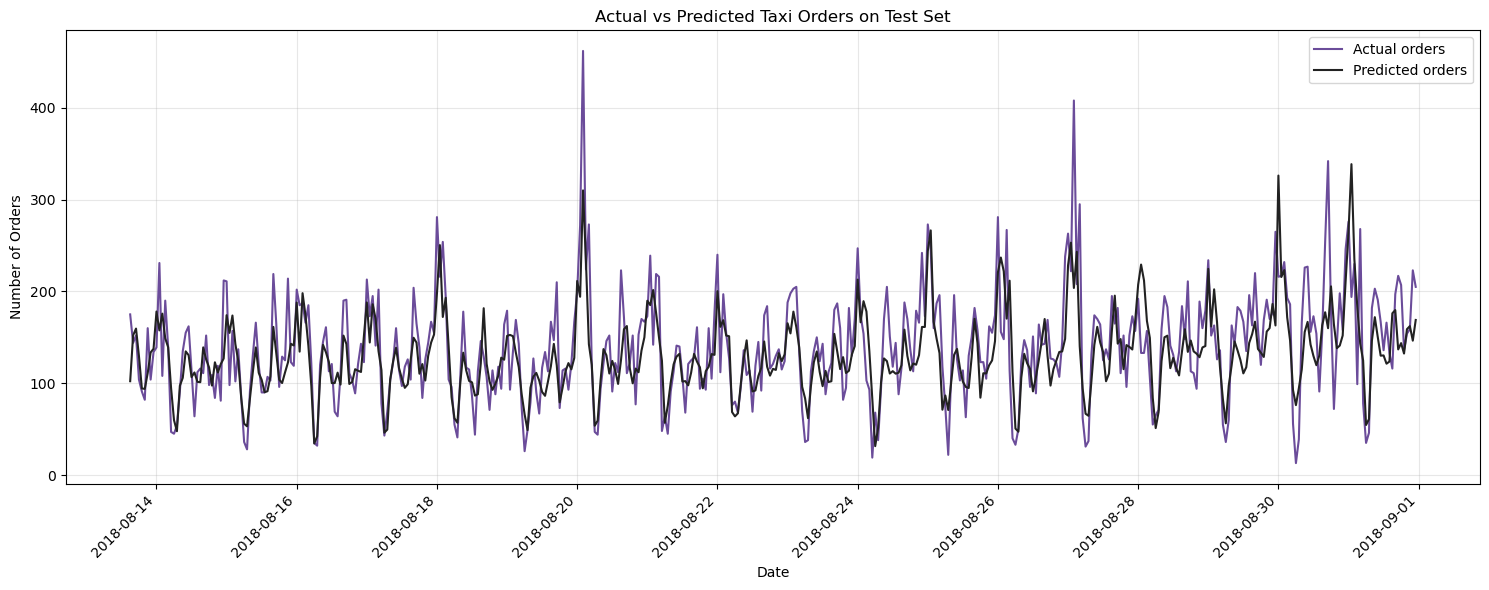

In [14]:
# 5.2 Actual vs Predicted Orders

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(y_test.index, y_test, label='Actual orders', color='#6B4C9A')
ax.plot(y_test.index, test_predictions, label='Predicted orders', color='#222222')

ax.set_title('Actual vs Predicted Taxi Orders on Test Set')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Orders')
ax.legend()
ax.grid(True, alpha=0.3)

# Improve date formatting on x-axis
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

The test-set plot shows that the predicted series follows the overall movement of the actual taxi orders quite closely. The model captures the general level of demand, the short-term ups and downs, and many of the local peaks and drops throughout the test period. This visual alignment supports the numerical result obtained from RMSE and indicates that the model generalizes reasonably well to unseen future observations.


At the same time, some of the largest spikes are not matched perfectly. 
In several cases, the model slightly underestimates or overestimates sharp demand surges, which is common in time series forecasting when irregular hourly shocks occur. Even so, the predicted curve remains close to the actual pattern for most of the test window.

Overall, the visual comparison confirms that the selected Gradient Boosting model provides a reliable forecast for next-hour taxi demand and performs well enough to satisfy the project requirement.

</div>

<div style="background-color:#e8f4fd; border-left:6px solid #1f77b4; padding:12px; border-radius:6px; color:#001f3f;">

In this project, historical taxi order data was prepared and resampled to hourly frequency in order to forecast the number of orders for the next hour. The dataset was first validated for missing values, duplicate timestamps, and continuity of the original time index, and no major quality issues were found. Exploratory analysis showed that the series contains a clear upward trend, strong daily seasonality, and changing variability over time. These findings indicated that the raw series is not stationary and that time-based feature engineering would be necessary for accurate forecasting.

To convert the time series into a supervised learning problem, calendar features, 24 lag variables, and a 24-hour rolling mean were created. Several models were then evaluated using time-series cross-validation, including Linear Regression, Decision Tree, Random Forest, and Gradient Boosting. Among all tested models, Gradient Boosting with 200 estimators and a learning rate of 0.1 achieved the best validation performance.

The final selected model was trained on the training set and evaluated on the untouched test set, where it achieved an RMSE of 41.37. This result is below the required threshold of 48, meaning the project goal was successfully achieved. Overall, the model provides an effective solution for forecasting short-term taxi demand and could help the company better plan driver availability during peak hours.

</div>